Corrective RAG - Correct Implementation

In [45]:
#libraries
import os
from typing import List
from typing_extensions import TypedDict
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langchain_text_splitters import RecursiveCharacterTextSplitter

LLM setup

In [46]:
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000020EA65B9C70>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000020EA65BBA10>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

Loading Docs

In [47]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]
docs = []
for url in urls:
    docs.extend(WebBaseLoader(url).load())
docs

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

Splitting the Docs

In [48]:
splitter = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=100)
splits = splitter.split_documents(docs)

Retriever and VectorStore Setup

In [49]:
embedding = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
embedding

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [50]:
vs = FAISS.from_documents(documents=docs,embedding=embedding)
retriever = vs.as_retriever(
    search_kwargs = {"k":4}
)
retriever

VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x0000020EC5225730>, search_kwargs={'k': 4})

Tavily Tool Setup

In [51]:
from langchain_tavily import TavilySearch
web_search_tool = TavilySearch(max_results=3)
web_search_tool

TavilySearch(max_results=3, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))

Format docs utility function

In [52]:
def format_docs(docs: List[Document]) -> str:
    return "\n\n".join(doc.page_content for doc in docs)

Output Models

In [53]:
class GradeDocs(BaseModel):
    binary_score: str = Field(description="Whether the document is relevant to the question. 'yes' or 'no'")

class GradeHallucination(BaseModel):
    binary_score: str = Field(description="Whether the answer is supported by the documents. 'yes' or 'no'")

class GradeAnswer(BaseModel):
    binary_score: str = Field(description="Whether the answer addresses the user's question. 'yes' or 'no'")

Retrieval Grader

In [54]:
retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
You are a grader assessing relevance of a retrieved document.

If the document contains keywords, concepts or semantic meaning
related to the user's question, grade it as relevant.

This is a lenient filter.

Respond only with 'yes' or 'no'.
""",
        ),
        (
            "human",
            """
Retrieved document:

{document}

User question:

{question}
""",
        ),
    ]
)

retrieval_grader = (
    retrieval_prompt
    | llm.with_structured_output(GradeDocs)
)
retrieval_grader

ChatPromptTemplate(input_variables=['document', 'question'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template="\nYou are a grader assessing relevance of a retrieved document.\n\nIf the document contains keywords, concepts or semantic meaning\nrelated to the user's question, grade it as relevant.\n\nThis is a lenient filter.\n\nRespond only with 'yes' or 'no'.\n"), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['document', 'question'], input_types={}, partial_variables={}, template='\nRetrieved document:\n\n{document}\n\nUser question:\n\n{question}\n'), additional_kwargs={})])
| _ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True

Answer Generator

In [55]:
rag_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are an intelligent assistant for Retrieval-Augmented Generation (RAG).

You will be given retrieved context and a user question.

Instructions:
- Answer ONLY using the provided context.
- If the answer cannot be determined from the context, say:
  "I don't have enough information in the provided documents to answer that."
- Do not make up facts.
- Do not use outside knowledge.
- Keep the answer clear, concise, and accurate.
- If appropriate, organize the answer using bullet points or numbered lists.
""",
        ),
        (
            "human",
            """Context:
{context}

Question:
{question}

Answer:""",
        ),
    ]
)

rag_chain = (
    rag_prompt
    | llm
    | StrOutputParser()
)
rag_chain

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an intelligent assistant for Retrieval-Augmented Generation (RAG).\n\nYou will be given retrieved context and a user question.\n\nInstructions:\n- Answer ONLY using the provided context.\n- If the answer cannot be determined from the context, say:\n  "I don\'t have enough information in the provided documents to answer that."\n- Do not make up facts.\n- Do not use outside knowledge.\n- Keep the answer clear, concise, and accurate.\n- If appropriate, organize the answer using bullet points or numbered lists.\n'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Context:\n{context}\n\nQuestion:\n{question}\n\nAnswer:'), additional_kwargs={})])
| Ch

Hallucination Grader

In [56]:
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
You are a grader assessing whether an answer is grounded in
retrieved documents.

Return:

yes → answer is supported

no → answer contains hallucinations

Respond only with 'yes' or 'no'.
""",
        ),
        (
            "human",
            """
Retrieved documents:

{documents}

LLM Answer:

{generation}
""",
        ),
    ]
)

hallucination_grader = (
    hallucination_prompt
    | llm.with_structured_output(GradeHallucination)
)
hallucination_grader

ChatPromptTemplate(input_variables=['documents', 'generation'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template="\nYou are a grader assessing whether an answer is grounded in\nretrieved documents.\n\nReturn:\n\nyes → answer is supported\n\nno → answer contains hallucinations\n\nRespond only with 'yes' or 'no'.\n"), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['documents', 'generation'], input_types={}, partial_variables={}, template='\nRetrieved documents:\n\n{documents}\n\nLLM Answer:\n\n{generation}\n'), additional_kwargs={})])
| _ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tok

Answer Grader

In [57]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
You are grading whether an answer addresses a user's question.

Respond with

yes

or

no
""",
        ),
        (
            "human",
            """
Question:

{question}

Generated answer:

{generation}
""",
        ),
    ]
)
answer_grader = (
    answer_prompt
    | llm.with_structured_output(GradeAnswer)
)
answer_grader

ChatPromptTemplate(input_variables=['generation', 'question'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template="\nYou are grading whether an answer addresses a user's question.\n\nRespond with\n\nyes\n\nor\n\nno\n"), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['generation', 'question'], input_types={}, partial_variables={}, template='\nQuestion:\n\n{question}\n\nGenerated answer:\n\n{generation}\n'), additional_kwargs={})])
| _ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'tex

Query Rewriter

In [58]:
rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
You are a query rewriter.

Rewrite the user's question to improve retrieval quality.

Do not answer the question.

Only rewrite it.
""",
        ),
        (
            "human",
            """
Original Question:

{question}
""",
        ),
    ]
)
query_rewriter = (
    rewrite_prompt
    | llm
    | StrOutputParser()
)
query_rewriter

ChatPromptTemplate(input_variables=['question'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template="\nYou are a query rewriter.\n\nRewrite the user's question to improve retrieval quality.\n\nDo not answer the question.\n\nOnly rewrite it.\n"), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['question'], input_types={}, partial_variables={}, template='\nOriginal Question:\n\n{question}\n'), additional_kwargs={})])
| ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False

Graph State

In [59]:
class GraphState(TypedDict):
    question: str
    documents: List[Document]
    generation: str
    web_search: str
    rewrite_count: int

Helper Debugger Function

In [60]:
def print_node(nodename: str):
    print("\n"+"="*60)
    print(f"Node: {nodename}")
    print("="*60)

Nodes Setup

Retrieve Node

In [61]:
def retrieve(state: GraphState):
    print_node("Retrieve")
    question = state["question"]
    documents = retriever.invoke(question)
    print(f"No of docs retrieved: {len(documents)}")
    return {
        "question": question,
        "documents": documents,
    }

Grade Docs Node

In [62]:
def grade_documents(state: GraphState):
    print_node("Grade Documents")
    question = state["question"]
    documents = state["documents"]
    filtered_docs = []
    web_search = "No"
    for i,doc in enumerate(documents):
        score = retrieval_grader.invoke(
            {
                "question": question,
                "document": doc.page_content,
            }
        )
        if score.binary_score.lower() == "yes":
            print(f"Doc{i+1} relevant")
            filtered_docs.append(doc)
        else:
            print(f"Doc{i+1} irrelevant")

    if len(filtered_docs) == 0:
        web_search = "Yes"
    return {
        "question": question,
        "documents": filtered_docs,
        "web_search": web_search,
    }

Rewrite Query Node

In [63]:
def transform_query(state: GraphState):
    print_node("Transform query")
    question = state["question"]
    better_question = query_rewriter.invoke(
        {
            "question": question
        }
    )

    print("Original :", question)
    print("Rewritten:", better_question)

    return {
        "question": better_question,
        "documents": state["documents"],
        "rewrite_count": state.get("rewrite_count",0)+1
    }

Web Search Node

In [64]:
def web_search_node(state: GraphState):
    print_node("Web Search")
    question = state["question"]
    documents = state["documents"]
    results = web_search_tool.invoke(
        {
            "query": question
        }
    )
    web_results = "\n\n".join(
        result["content"] for result in results
    )
    documents.append(
        Document(page_content=web_results)
    )
    print("Web results added.")
    return {
        "question": question,
        "documents": documents,
    }

Generate Answer Node

In [65]:
def generate(state: GraphState):
    print_node("Generate")
    question = state["question"]
    documents = state["documents"]
    generation = rag_chain.invoke(
        {
            "context": format_docs(documents),
            "question": question,
        }
    )
    return {
        "question": question,
        "documents": documents,
        "generation": generation,
    }

Grade Generation Node

In [66]:
def grade_generation_wrt_documents_and_question(
    state: GraphState,
):
    print_node("Grade Generation")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]
    hallucination_score = hallucination_grader.invoke(
        {
            "documents": format_docs(documents),
            "generation": generation,
        }
    )
    if hallucination_score.binary_score.lower() == "yes":
        print("Generation grounded.")
        answer_score = answer_grader.invoke(
            {
                "question": question,
                "generation": generation,
            }
        )
        if answer_score.binary_score.lower() == "yes":
            print("Answer addresses question.")
            return "useful"
        else:
            print("Answer does not address question.")
            return "not useful"
    else:
        print("Hallucination detected.")
        return "not supported"

Node to decide if generate or rewrite

In [67]:
MAX_REWRITES = 2
def decide_to_generate(state: GraphState):
    print_node("Decide to generate")
    if state["web_search"] == "Yes":
        if state.get("rewrite_count", 0) >= MAX_REWRITES:
            print("Maximum rewrites reached.")
            print("Proceeding with available documents.")
            return "generate"
        print("Documents insufficient.")
        print("Rewriting query...")
        return "transform_query"

    print("Documents sufficient.")
    print("Generating answer...")
    return "generate"

Building graph

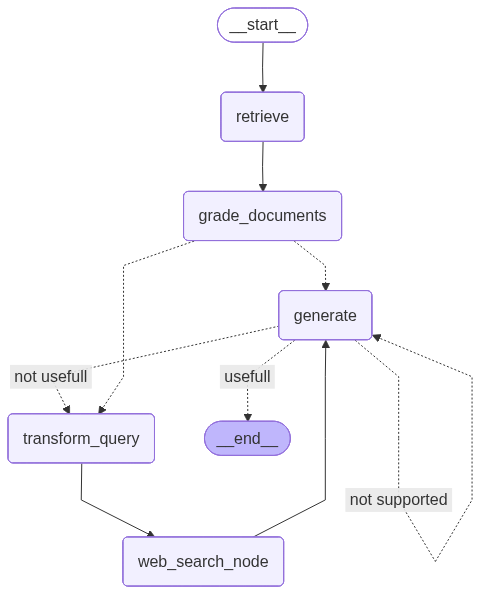

In [68]:
workflow = StateGraph(GraphState)

#nodes
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents",grade_documents)
workflow.add_node("transform_query",transform_query)
workflow.add_node("web_search_node",web_search_node)
workflow.add_node("generate",generate)

#edges
workflow.add_edge(START,"retrieve")
workflow.add_edge("retrieve","grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query":"transform_query",
        "generate":"generate"
    }
)
workflow.add_edge("transform_query","web_search_node")
workflow.add_edge("web_search_node","generate")
workflow.add_conditional_edges(
    "generate",
    grade_generation_wrt_documents_and_question,
    {
        "usefull": END,
        "not usefull": "transform_query",
        "not supported": "generate"
    }
)
graph = workflow.compile()
from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

Testing 

In [69]:
inputs = {
    "question": "What are autonomous agents?",
    "rewrite_count": 0,
}

result = graph.invoke(inputs)


Node: Retrieve
No of docs retrieved: 3

Node: Grade Documents
Doc1 relevant
Doc2 relevant


APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `llama-3.3-70b-versatile` in organization `org_01kvj5s29efhr9w67feczgxz75` service tier `on_demand` on tokens per minute (TPM): Limit 12000, Requested 12870, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}